# A2: Frequency response

In engineering, unlike in cell electrophysiology, the most interesting part of a system is often how it responds to a (co)sinusoidal input.
This is called its _frequency response_, and is discussed in this notebook.

Contents:

- [Manual calculation example](#Manual-calculation-example)
- [General frequency response](#General-frequency-response)


## Manual calculation example

The straightforward way to find a frequency response is to write out the system as $Y(s) = H(s) U(s)$, fill in the Laplace transform of a sine or cosine for $U(s)$, multiplying, and then then working out the inverse transform.

We will do this below, and work out several important concepts along the way.
Then, in the next section, we will find a much easier method.

The example we use is a [low-pass filter](https://en.wikipedia.org/wiki/Low-pass_filter), for example the schematic below:

<img src="./img/rc-1-simple.png" />

### Deriving a transfer function

Using Kirchoff's laws we write a differential equation for $V$ in terms of $V_\text{in}$

\begin{align}
\left.
\begin{aligned}
&V - V_\text{in} = I_R R \\
&I_R = I_C = C\frac{d}{dt}(0 - V) = -C\dot{V} \\
\end{aligned}
\right\}V - V_\text{in} = -RC\dot{V}
\end{align}

Using $\omega = 1/RC$

\begin{align}
\dot{V}(t) = \omega\left(V_\text{in}(t) - V(t)\right)
\end{align}

Apply a Laplace transformation, with initial conditions $V(0)=0$:

\begin{align}
s V(s) &= \omega(V_\text{in}(s) - V(s)) \\
V &= V_\text{in} \omega / (s + \omega)
\end{align}

Then find the transfer function by dividing by $U(s) = V_\text{in}(s)$ for

\begin{align}
H(s) &= \frac{\omega}{s + \omega}
\end{align}

### Finding the output

To see why this is called a "low-pass filter", we apply the input

\begin{align}
u(t) = \cos(\phi t)
    \quad\longrightarrow\quad
U(s) = \frac{s}{s^2 + \phi^2}
\end{align}
to get
\begin{align}
Y(s) = H(s)U(s) = \frac{\omega s}{(s + \omega)(s^2 + \phi^2)}
\end{align}

Partial fraction decomposition lets us write this as 
\begin{align}
Y(s) = \frac{A}{s + \omega} + \frac{B s + C}{s^2 + \phi^2}
\end{align}

which we can bring under a common denominator and expand to

\begin{align}
Y(s) = \frac{s^2(A + B) + s(B\omega + C) + (A\phi^2 + C\omega)}{(s + \omega)(s^2 + \phi^2)}
\end{align}

which holds if $B = -A$ and $C = -\frac{\phi^2}{\omega}A$.
For $A$ itself we find
\begin{align}
\omega = B\omega + C = -A\omega - \frac{\phi^2}{\omega}A
    \,\longrightarrow\,
A = \frac{\omega}{-\omega - \phi^2/\omega} = \frac{-\omega^2}{\omega^2 + \phi^2}
\end{align}

Filling in expressions for $B$ and $C$ we arrive at

\begin{align}
Y(s) = A\frac{1}{s + \omega} -A\frac{s}{s^2 + \phi^2} - A\frac{\phi}{\omega}\frac{\phi}{s^2 + \phi^2}
\end{align}

which translates back easily to

\begin{align}
y(t) = Ae^{-\omega t} -A\left[\cos(\phi t) + \frac{\phi}{\omega}\sin(\phi t)\right]
\end{align}

This shows us that the response can be broken up into two parts: a **transient response**, depending only on (A and) the filter frequency $\omega$, and a **periodic response**, with the frequency of the input signal, $\phi$.

#### Intermezzo: the harmonic addition theorem

To simplify further we need something known as the "harmonic addition theorem", which shows that we can write the grouped terms above as a single cosine with a phase shift:
$$a\cos(x) + b\sin(x) = c\cos(x + z)$$

to see that this is true and find the appropriate $c$ and $z$ we write

\begin{align}
a\cos(x) + b\sin(x) &= c\cos(x + z) \\
                    &= c\cos(x)\cos(z) - c\sin(x)\sin(z)
\end{align}
so that
\begin{align}
\left.\begin{aligned} a &= c\cos(z) \\ b &= -c\sin(z) \end{aligned}\right\}
\quad \tan{z}=\frac{\sin(y)}{\cos(z)}=\frac{-b}{a}
\quad \longrightarrow \quad z = \arctan(-b/a)
\end{align}
and
$$a^2 + b^2 = c^2\cos^2(z) + c^2\sin^2(z) = c^2 \quad \longrightarrow \quad c = \pm \sqrt{a^2 + b^2}$$

##### Form using sign(a)

Finally, because $\arctan$ by definition returns a value $z \in (-\pi/2, \pi/2)$ we have $\cos(z) \geq 0$ and so $a$ and $c$ must have the same sign, denoted $\operatorname{sign}(a)$.
This gives us the final result:

\begin{align}
a\cos(x) + b\sin(x) = \operatorname{sign}(a)\sqrt{a^2+b^2} \cos(x + \arctan(-b/a))
\end{align}

##### Atan2 form

Alternatively, we can use [atan2(b, a)](https://en.wikipedia.org/wiki/Atan2).
This differs from $\arctan(b/a)$ by either $+\pi$ or $-\pi$ whenever $a < 0$, and since $\cos(x \pm \pi) = -\cos(x)$  this means the $\cos$ will have the same sign as $a$ so that we can write:

\begin{align}
a\cos(x) + b\sin(x) = \sqrt{a^2+b^2} \cos(x + \operatorname{atan2}(-b, a))
\end{align}

#### Back to the low-pass filter!

Filling in $a = 1$ and $b = \phi / \omega$ we get
\begin{align}\cos(\phi t) + \frac{\phi}{\omega}\sin(\phi t) 
    &= \operatorname{sign}(1)\sqrt{1 + \phi^2/\omega^2} \cos\left(\phi t + \arctan(-\phi / \omega)\right) \\
    &= \sqrt{1 + \phi^2/\omega^2} \cos\left(\phi t - \arctan(\phi / \omega)\right)
\end{align}

The complete response becomes

\begin{align}
y(t) &= \frac{-\omega^2}{\omega^2 + \phi^2} e^{-\omega t} - \frac{-\omega^2}{\omega^2 + \phi^2} \sqrt{1 + \phi^2/\omega^2} \cos\left(\phi t - \arctan(\phi / \omega)\right) \\
    &= -\frac{\omega^2}{\omega^2 + \phi^2} e^{-\omega t} + \frac{\omega}{\sqrt{\omega^2 + \phi^2}} \cos\left(\phi t - \arctan(\phi / \omega)\right) \\
\end{align}

This clearly shows the **transient part** on the left, and the **periodic part** on the right, which has **the same frequency** as the input signal but a **phase shift** depending on the ratio of the input frequency to the filter frequency.
Both terms have an amplification or gain factor depending on both frequencies.

#### Interpreting the result

We applied an input $\cos(\phi t)$ and got a response consisting of an exponentially decaying term and an oscillation.
To analyse this further, let $\lambda = \phi / \omega$ be the ratio between the input and the filter frequencies, so that $\lambda > 1$ means the input frequency exceeds the filter frequency.
The equation above then simplifies to
\begin{align}
y(t) = -\frac{1}{1 + \lambda^2} e^{-\omega t} 
     + \frac{1}{\sqrt{1 + \lambda^2}} \cos\left(\phi t - \arctan(\lambda) \right)
\end{align}

This means that, once the transient response has died out, the main effect of the filter is to apply a phase shift and a frequency-dependent scaling $(1 + \lambda^2)^{-1/2}$.
We can plot this response on a linear scale or, as is more commonly done, on a log-log scale:

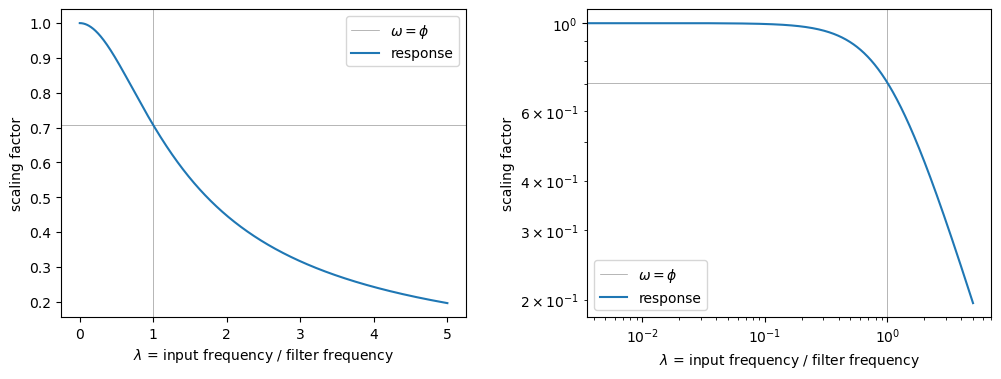

In [1]:
import matplotlib.pyplot as plt
import numpy as np

f = lambda x: 1 / np.sqrt(1 + x**2)

x = np.linspace(0, 5, 1001)
y = f(x)

fig = plt.figure(figsize=(12, 4))
fig.subplots_adjust(wspace=0.3)

ax = plt.subplot(1, 2, 1)
ax.set_xlabel(r'$\lambda$ = input frequency / filter frequency')
ax.set_ylabel('scaling factor')
ax.axvline(1, color='#999', lw=0.5, label=r'$\omega = \phi$')
ax.axhline(f(1), color='#999', lw=0.5)
ax.plot(x, y, label='response')
ax.legend()

ax = plt.subplot(1, 2, 2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\lambda$ = input frequency / filter frequency')
ax.set_ylabel('scaling factor')
ax.axvline(1, color='#999', lw=0.5, label=r'$\omega = \phi$')
ax.axhline(f(1), color='#999', lw=0.5)
ax.plot(x, y, label='response')
ax.legend()

plt.show()

Looking at the linear plot, we can clearly see that the filter has a strong effect on frequencies above $\omega$, but already provides significant damping even at $\phi = \omega$.
In the log-log plot the effect seems a bit more dramatic: for $\phi \approx 10^{-1} \omega$ there is very little filtering, but anything higher gets filtered out.

This finally shows us why it's called a "low-pass" filter: only low frequencies (relative to $\omega$) pass through unattenuated.

When combined with a plot of the phase shift, the log-log plot above is called a [Bode plot](https://en.wikipedia.org/wiki/Bode_plot).
In many engineering applications the transient response is uninteresting (provided it can be made short), so people usually don't bother with all the above to figure it out.
Instead, they look only at the _frequency response_.

### Corner frequency and bandwidth

At $\phi = \omega$, the filter reduces the signal by a factor $1 / \sqrt{1 + \lambda^2} = 1 / \sqrt{2}$.
Because the _power_ of this signal is proportional to its square, $1/2$, and because $^{10}\log(1/2) \approx -3.01$ this is also known as the "3[dB](https://en.wikipedia.org/wiki/Decibel) point".

In [2]:
amplitude = 1 / np.sqrt(2)  # The amplitude at phi=omega is 1/sqrt(2)
power = amplitude**2        # The power is proportional to amplitude**2
10*np.log10(1/2)            # Engineers like decibels

-3.010299956639812

In general, any frequency at which a filter's gain drops to $\sqrt{1/2}$ is known as a _cutoff_ or [_corner frequency_](https://en.wikipedia.org/wiki/Cutoff_frequency).

The width of the range of frequencies with a gain above $\sqrt{1/2}$ is called the [bandwidth](https://en.wikipedia.org/wiki/Bandwidth_(signal_processing)).
For the low-pass filter above, both the cutoff frequency and the bandwidth have the value $\omega$.

### The low-pass filter's response to cosine and sine

In summary, for the low-pass filter and a cosine input we found

\begin{align}
y(t) &= -\frac{\omega^2}{\omega^2 + \phi^2} e^{-\omega t} + \frac{\omega}{\sqrt{\omega^2 + \phi^2}} \cos\left(\phi t - \arctan(\phi / \omega)\right) \\
    &= -\frac{1}{1 + \lambda^2} e^{-\omega t} + \frac{1}{\sqrt{1 + \lambda^2}} \cos\left(\phi t - \arctan(\lambda) \right)
\end{align}

where $\lambda = \phi / \omega$.

We can repeat with a $\sin$ input to find

\begin{align}
y(t) &= \frac{\omega\phi}{\omega^2 + \phi^2} e^{-\omega t} 
     + \frac{\omega}{\sqrt{\omega^2 + \phi^2}} \sin\left(\phi t - \arctan(\phi/\omega)\right) \\
     &= \frac{\lambda}{1 + \lambda^2} e^{-\omega t} 
     + \frac{1}{\sqrt{1 + \lambda^2}} \sin\left(\phi t - \arctan(\lambda)\right)
\end{align}

### Simulating a low-pass filter

We now use Myokit to simulate three cases: $\lambda = 1/2$, $\lambda = 1$, and $\lambda = 2$.

First we define a model for the cosine case:

In [3]:
import myokit

cos_model = myokit.parse_model('''
[[model]]
rc.v0 = 0
rc.v1 = 0
rc.v2 = 0
input(time, omega, lambda) = cos(lambda * omega * time)

[rc]
t = 0 bind time
omega = 2
cos0 = input(t, omega, 1 / 2)
cos1 = input(t, omega, 1)
cos2 = input(t, omega, 2)
dot(v0) = (cos0 - v0) * omega
dot(v1) = (cos1 - v1) * omega
dot(v2) = (cos2 - v2) * omega
''')

Next, we'll run a simulation and plot the results:

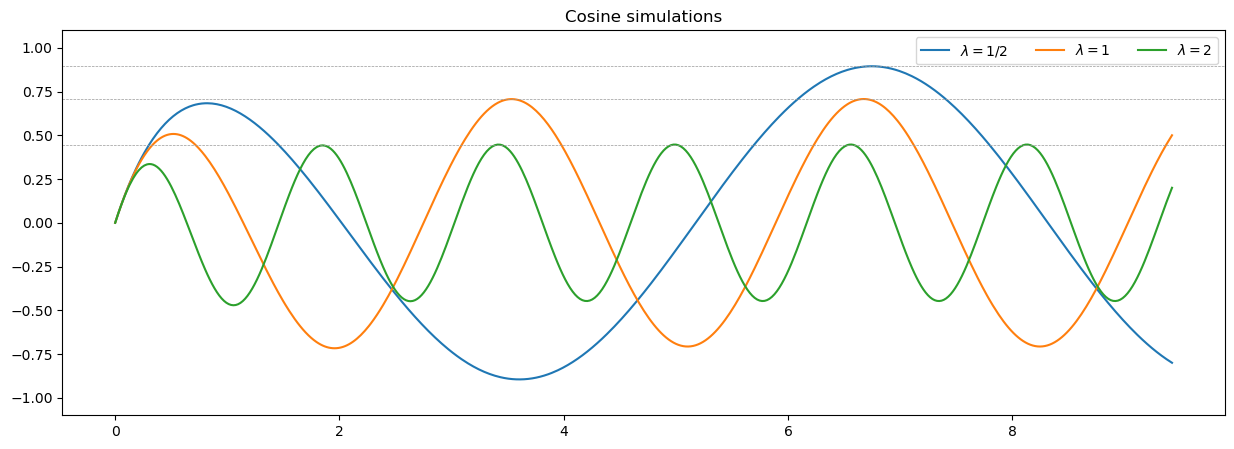

In [4]:
sim = myokit.Simulation(cos_model)
sim.set_tolerance(1e-8, 1e-8)
log = sim.run(np.pi * 3).npview()
t = log.time()

def amplitude(x):
    """Expected amplitude"""
    return 1 / np.sqrt(1 + x**2)

fig = plt.figure(figsize=(15, 5))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Cosine simulations')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, log['rc.v0'], label=r'$\lambda = 1/2$')
ax.plot(t, log['rc.v1'], label=r'$\lambda = 1$')
ax.plot(t, log['rc.v2'], label=r'$\lambda = 2$')
kw = dict(color='#999', lw=0.5, ls='--')
ax.axhline(amplitude(1/2), **kw)
ax.axhline(amplitude(1), **kw)
ax.axhline(amplitude(2), **kw)
ax.legend(ncols=3)

plt.show()

This shows the simulated voltages all starting at $V(t=0) = 0$, but then quickly adapting to become proper cosines.
Each signal is attenuated during the first period, but by the second period we see the peaks reach the expected amplitude for a pure signal.


To check if our maths was any good, we can define functions using the derived equations for the transient and periodic terms, and compare them to the simulations:

In [5]:
omega = cos_model.get('rc.omega').eval()

def cos_transient(t, x):
    """Transient, using x=lambda."""
    return -1 / (1 + x**2) * np.exp(-omega * t)

def cos_periodic(t, x):
    """Sine wave with gain and phase shift."""
    return 1 / np.sqrt(1 + x**2) * np.cos(omega * x * t - np.arctan(x))

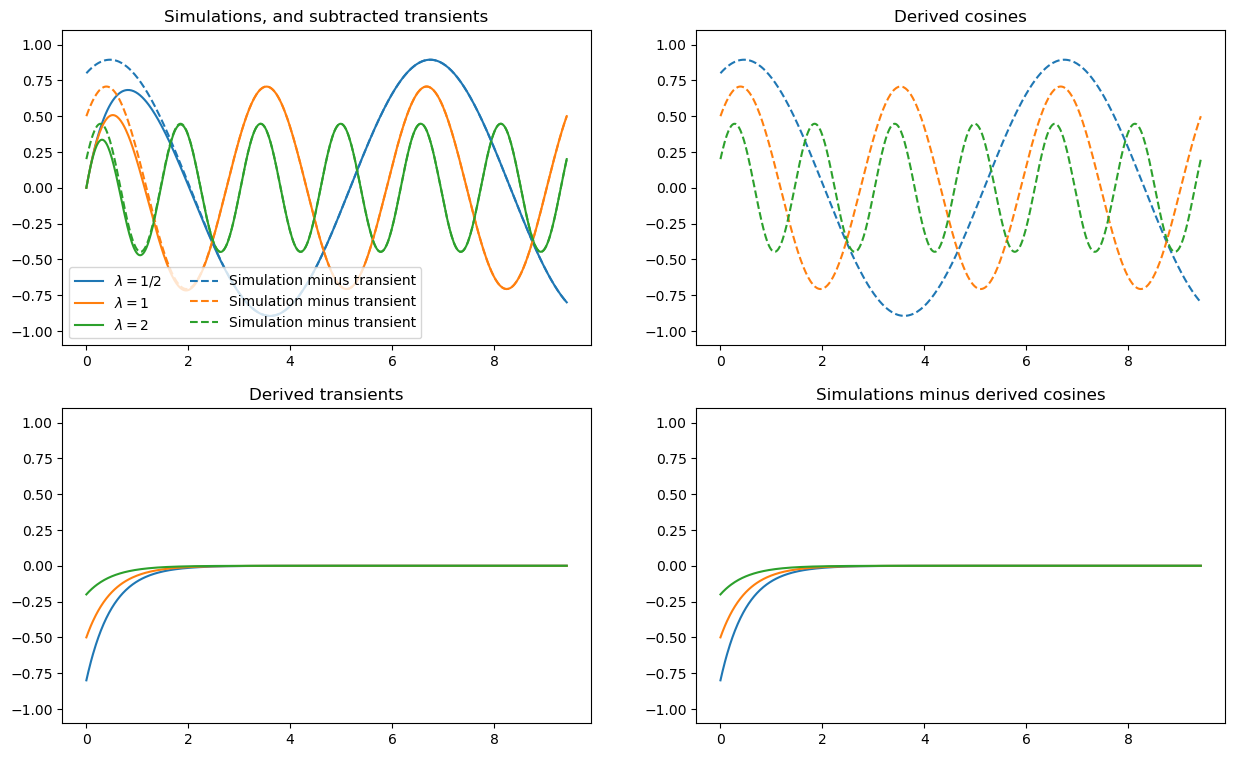

In [6]:
fig = plt.figure(figsize=(15, 9))

ax = fig.add_subplot(2, 2, 1)
ax.set_title('Simulations, and subtracted transients')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, log['rc.v0'], label=r'$\lambda = 1/2$')
ax.plot(t, log['rc.v1'], label=r'$\lambda = 1$')
ax.plot(t, log['rc.v2'], label=r'$\lambda = 2$')
ax.plot(t, log['rc.v0'] - cos_transient(t, 1/2), '--', color='tab:blue', label='Simulation minus transient')
ax.plot(t, log['rc.v1'] - cos_transient(t, 1), '--', color='tab:orange', label='Simulation minus transient')
ax.plot(t, log['rc.v2'] - cos_transient(t, 2), '--', color='tab:green', label='Simulation minus transient')
ax.legend(ncols=2)

ax = fig.add_subplot(2, 2, 2)
ax.set_title('Derived cosines')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, cos_periodic(t, 0.5), '--', color='tab:blue') 
ax.plot(t, cos_periodic(t, 1), '--', color='tab:orange')
ax.plot(t, cos_periodic(t, 2), '--', color='tab:green')

ax = fig.add_subplot(2, 2, 3)
ax.set_title('Derived transients')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, cos_transient(t, 0.5))
ax.plot(t, cos_transient(t, 1))
ax.plot(t, cos_transient(t, 2))

ax = fig.add_subplot(2, 2, 4)
ax.set_title('Simulations minus derived cosines')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, log['rc.v0'] - cos_periodic(t, 0.5))
ax.plot(t, log['rc.v1'] - cos_periodic(t, 1))
ax.plot(t, log['rc.v2'] - cos_periodic(t, 2))

plt.show()

We can repeat the exercise for the sine wave equations:

In [7]:
sin_model = myokit.parse_model('''
[[model]]
rc.v0 = 0
rc.v1 = 0
rc.v2 = 0
input(time, omega, lambda) = sin(lambda * omega * time)

[rc]
t = 0 bind time
omega = 2
sin0 = input(t, omega, 1 / 2)
sin1 = input(t, omega, 1)
sin2 = input(t, omega, 2)
dot(v0) = (sin0 - v0) * omega
dot(v1) = (sin1 - v1) * omega
dot(v2) = (sin2 - v2) * omega
''')

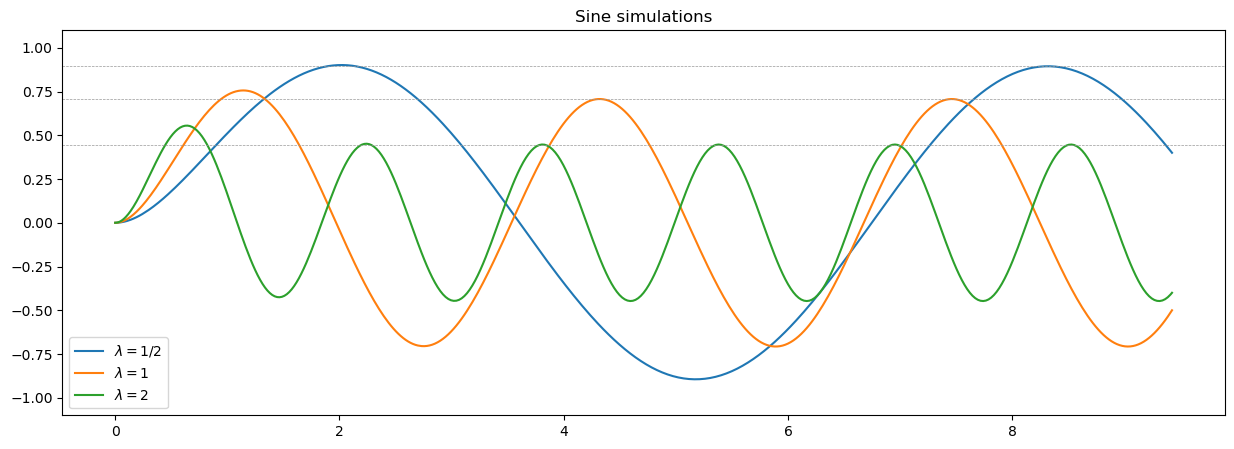

In [8]:
sim = myokit.Simulation(sin_model)
sim.set_tolerance(1e-8, 1e-8)
log = sim.run(np.pi * 3).npview()
t = log.time()

fig = plt.figure(figsize=(15, 5))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Sine simulations')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, log['rc.v0'], label=r'$\lambda = 1/2$')
ax.plot(t, log['rc.v1'], label=r'$\lambda = 1$')
ax.plot(t, log['rc.v2'], label=r'$\lambda = 2$')
kw = dict(color='#999', lw=0.5, ls='--')
ax.axhline(amplitude(1/2), **kw)
ax.axhline(amplitude(1), **kw)
ax.axhline(amplitude(2), **kw)
ax.legend()

plt.show()

Consistent with the positive transient term, the signals now all start off with high amplitudes before settling down to the expected filtering level.

Next, we perform the same checks as before:

In [9]:
omega = sin_model.get('rc.omega').eval()

def sin_transient(t, x):
    """Transient, using x=lambda."""
    return x / (1 + x**2) * np.exp(-omega * t)

def sin_periodic(t, x):
    """Sine wave with gain and phase shift."""
    return 1 / np.sqrt(1 + x**2) * np.sin(omega * x * t - np.arctan(x))

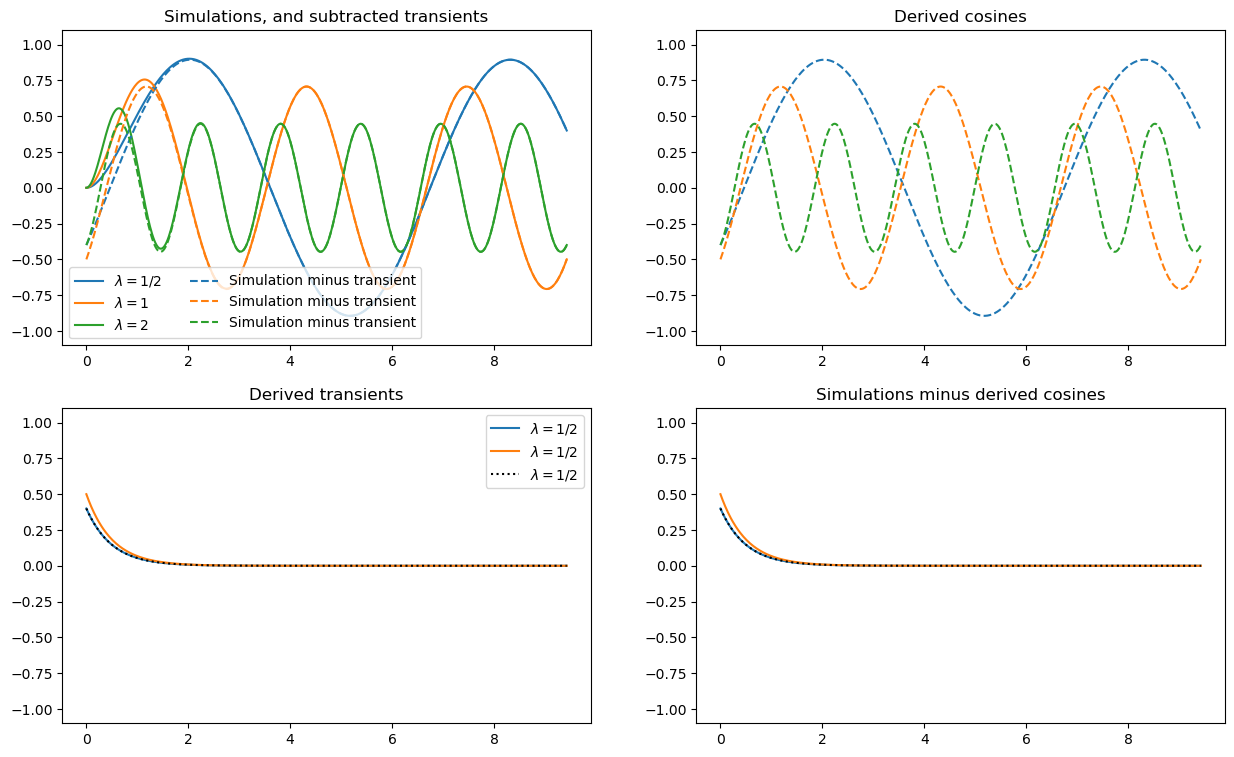

In [10]:
fig = plt.figure(figsize=(15, 9))

ax = fig.add_subplot(2, 2, 1)
ax.set_title('Simulations, and subtracted transients')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, log['rc.v0'], label=r'$\lambda = 1/2$')
ax.plot(t, log['rc.v1'], label=r'$\lambda = 1$')
ax.plot(t, log['rc.v2'], label=r'$\lambda = 2$')
ax.plot(t, log['rc.v0'] - sin_transient(t, 1/2), '--', color='tab:blue', label='Simulation minus transient')
ax.plot(t, log['rc.v1'] - sin_transient(t, 1), '--', color='tab:orange', label='Simulation minus transient')
ax.plot(t, log['rc.v2'] - sin_transient(t, 2), '--', color='tab:green', label='Simulation minus transient')
ax.legend(ncols=2)

ax = fig.add_subplot(2, 2, 2)
ax.set_title('Derived cosines')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, sin_periodic(t, 0.5), '--', color='tab:blue') 
ax.plot(t, sin_periodic(t, 1), '--', color='tab:orange')
ax.plot(t, sin_periodic(t, 2), '--', color='tab:green')

ax = fig.add_subplot(2, 2, 3)
ax.set_title('Derived transients')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, sin_transient(t, 0.5), label=r'$\lambda=1/2$')
ax.plot(t, sin_transient(t, 1), label=r'$\lambda=1/2$')
ax.plot(t, sin_transient(t, 2), 'k:', label=r'$\lambda=1/2$')
ax.legend()

ax = fig.add_subplot(2, 2, 4)
ax.set_title('Simulations minus derived cosines')
ax.set_ylim(-1.1, 1.1)
ax.plot(t, log['rc.v0'] - sin_periodic(t, 0.5))
ax.plot(t, log['rc.v1'] - sin_periodic(t, 1))
ax.plot(t, log['rc.v2'] - sin_periodic(t, 2), 'k:')

plt.show()

## General frequency response

To see how the above examples generalise, we start with an impulse response $h(t)$ **for a stable system**, a cosine input, and $t >= 0$:

$$u(t) = \cos(\omega t)$$
to get output
$$y(t) = \int_0^t h(\tau)\cos(\omega(t - \tau))d\tau$$

Next, we change the integration bounds to rewrite this as

$$y(t) = \int_0^\infty h(\tau)\cos(\omega(t - \tau))d\tau - \int_t^\infty h(\tau)\cos(\omega(t - \tau))d\tau$$

The advantage of this formulation becomes apparent by considering the role of $h(\tau)$ in both terms.
Because we defined our system as _stable_, its impulse response $h$ should be greatest at $t=0$ and then dampen out.
As a result, the second integral should become smaller and smaller as we start at larger $t$.

For example, if the impulse response is a decaying exponential in the time domain:

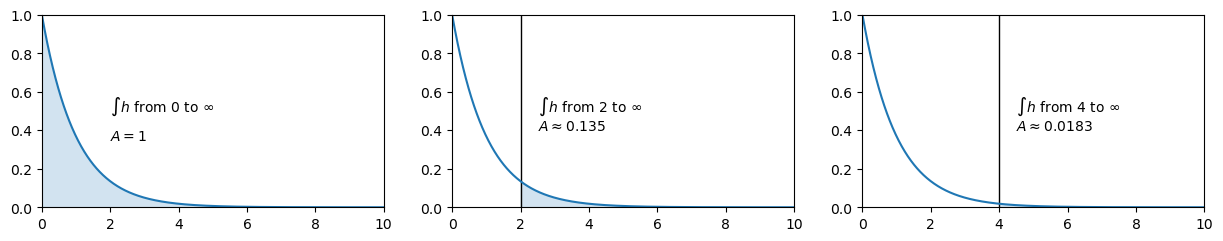

In [11]:
fig = plt.figure(figsize=(15, 2.5))

f = lambda x: np.exp(-x)
x = np.linspace(0, 10, 1001)
y = f(x)

ax = fig.add_subplot(1, 3, 1)
ax.set_xlim(0, 10); ax.set_ylim(0, 1)
ax.plot(x, y)
ax.fill_between(x, y, alpha=0.2)
ax.text(2, 0.5, r'$\int h$ from 0 to $\infty$')
ax.text(2, 0.35, '$A=1$')

ax = fig.add_subplot(1, 3, 2)
ax.set_xlim(0, 10); ax.set_ylim(0, 1)
ax.axvline(x[200], color='k', lw=1)
ax.plot(x, y)
ax.fill_between(x[200:], y[200:], alpha=0.2)
ax.text(2.5, 0.5, r'$\int h$ from 2 to $\infty$')
ax.text(2.5, 0.4, f'$A\\approx{np.exp(-2):.3}$')

ax = fig.add_subplot(1, 3, 3)
ax.set_xlim(0, 10); ax.set_ylim(0, 1)
ax.axvline(x[400], color='k', lw=1)
ax.plot(x, y)
ax.fill_between(x[400:], y[400:], alpha=0.2)
ax.text(4.5, 0.5, r'$\int h$ from 4 to $\infty$')
ax.text(4.5, 0.4, f'$A \\approx{np.exp(-4):.3}$')

plt.show()

By contrast, the integral in the first term
$$y_{ss}(t) = \int_0^\infty h(\tau)\cos(\omega(t - \tau))d\tau$$
is always taken from 0 to $\infty$, so over the full range of $h$, capturing its full "weight" of 1.

This splits the system into a **periodic steady-state response** (first term) and a **transient response** (second term).

Assuming that we're only interested in the periodic steady-state response, $y_{ss}$, we can then analyse the system by looking at $y_{ss}$ exclusively:

\begin{align}
y_{ss}(t)
    &= \int_0^\infty h(\tau)\cos(\omega(t - \tau))d\tau \\
    &= \frac{1}{2} \int_0^\infty h(\tau)\left(e^{i\omega(t - \tau)} + e^{-i\omega(t - \tau)}\right)d\tau \\
    &= \frac{1}{2} e^{i\omega t} \int_0^\infty h(\tau)e^{-i\omega\tau} d\tau +
       \frac{1}{2} e^{-i\omega t} \int_0^\infty h(\tau)e^{i\omega\tau} d\tau \\
    &= \frac{1}{2} e^{i\omega t} H(i\omega) + \frac{1}{2} e^{-i\omega t} H(-i\omega) \\
\end{align}

where we have isolated $H(i\omega)$ and $H(-i\omega)$: two _evaluations_ of the transfer function!

To go further, we first need to show that $H(-i\omega)$ and $H(i\omega)$ are each other's complex conjugates, i.e. $\overline{H(-i\omega)}=H(i\omega)$.
We can do this simply by writing them out:

\begin{align}
H(-i\omega) = \int_0^\infty h(t)e^{i\omega t}dt
            = \int_0^\infty h(t)\cos(\omega t)dt + i \int_0^\infty h(t)\sin(\omega t)dt
\end{align}

Here the first and second terms are the real and imaginary parts of $H(-i\omega)$ (because $h$ and $\cos$ and $\sin$ all return real values).
We do the same for $H(i\omega)$:

\begin{align}
H(i\omega) &= \int_0^\infty h(t)e^{-i\omega t}dt \\
           &= \int_0^\infty h(t)\cos(-\omega t)dt + i \int_0^\infty h(t)\sin(-\omega t)dt \\
           &= \int_0^\infty h(t)\cos(\omega t)dt - i \int_0^\infty h(t)\sin(\omega t)dt \\
           &= \overline{H(-i\omega)} &
\end{align}

Now, using $R=\operatorname{Re}(H(i\omega))$ and $I=\operatorname{Im}(H(i\omega))$ we can write

\begin{align}
y_{ss}(t)
    &= \frac{1}{2} \left[ e^{i\omega t} H(i\omega) + e^{-i\omega t} H(-i\omega) \right] \\
    &= \frac{1}{2} \left[ e^{i\omega t} H(i\omega) + e^{-i\omega t} \overline{H(i\omega)} \right] \\
    &= \frac{1}{2} \left[ e^{i\omega t} R + i e^{i\omega t} I + e^{-i\omega t} R - i e^{-i\omega t} I \right] \\
    &= \frac{1}{2} \left[ (e^{i\omega t} + e^{-i\omega t}) R + i (e^{i\omega t} - i e^{-i\omega t}) I \right] \\
    &= R\cos(\omega t) - I\sin(\omega t) \\
\end{align}

Finally, using the harmonic addition theorem in atan2 form (see above), we get

\begin{align}
y_{ss}(t) = |H(i\omega)| \cos(\omega t + \angle H(i\omega))
\end{align}

where $|H(iw)| = \sqrt{R^2 + I^2}$ and $\angle H(i\omega) = \operatorname{atan2}(I, R)$.

This shows that we can write a **stable** system's _periodic steady state response_ to a cosine input with frequency $\omega$ in terms of the transfer function evaluated at $H(i\omega)$.
If we allow $\omega$ to vary, the resulting function $H(i\omega)$ is called the system's _frequency response_.

Repeating the steps above with a sine input, we find

\begin{align}
y_{ss,cos}(t) = |H(i\omega)| \cos(\omega t + \angle H(i\omega)) \\
y_{ss,sin}(t) = |H(i\omega)| \sin(\omega t + \angle H(i\omega))
\end{align}

## Frequency response of filters

A general strategy to analyse filters is to look at $H(i\omega)$, work out $|H(i\omega)|$ and $\angle H(i\omega)$, and then make a Bode plot.

Below, we show this for three simple filters.

### The first-order low-pass filter

We now apply this general procedure to the low-pass filter we analysed before.
Because we used $\omega$ for its filter frequency, we'll use $\phi$ for the input frequency and $H(i\phi)$ for the frequency response.

\begin{align}
H(s) &= \frac{\omega}{s + \omega} \\
H(i\phi) &= \frac{\omega}{\omega+i\phi}
         = \frac{\omega(\omega-i\phi)}{(\omega+i\phi)(\omega-i\phi)}
         = \frac{\omega^2 - i\omega\phi}{\omega^2 + \phi^2}
\end{align}

\begin{align}
|H(i\phi)| = \frac{|\omega|}{|\omega+i\phi|}
           = \frac{\omega}{\sqrt{\omega^2 + \phi^2}}
\end{align}

\begin{align}
\angle H(i\phi) = \arctan(-\omega\phi / \omega^2) 
                = \arctan(-\phi / \omega)
                = -\arctan(\phi / \omega)
\end{align}

And so
\begin{align}
y_{ss,\cos} &= \frac{\omega}{\sqrt{\omega^2 + \phi^2}} \cos\left(\phi t - \arctan(\phi/\omega)\right) \\
y_{ss,\sin} &= \frac{\omega}{\sqrt{\omega^2 + \phi^2}} \sin\left(\phi t - \arctan(\phi/\omega)\right)
\end{align}

To make the bode plot:

In [12]:
def bode(mag, arg, axes=None, lo=1e-2, hi=1e5, **kwargs):
    lo, hi = np.log10(lo), np.log10(hi)
    w = np.logspace(lo, hi, 1001, base=np.e)

    if axes is None:
        fig = plt.figure(figsize=(9, 6))
        fig.subplots_adjust(hspace=0.2)
        ax0 = fig.add_subplot(2, 1, 1)
        ax0.set_xscale('log')
        ax0.set_yscale('log')
        ax0.set_ylabel('Gain')
        ax0.grid()

        ax1 = fig.add_subplot(2, 1, 2)
        ax1.set_xscale('log')
        ax1.set_xlabel('Angular frequency')
        ax1.set_ylabel('Phase shift (degrees)')
        ax1.grid()
    else:
        ax0, ax1 = axes

    label=None
    if kwargs:
        label=','.join(f'{k}={v}' for k, v in kwargs.items())

    ax0.plot(w, mag(w, **kwargs), label=None)
    ax1.plot(w, arg(w, **kwargs) * 180 / np.pi, label=label)
    if label is not None:
        ax1.legend()
       
    return ax0, ax1

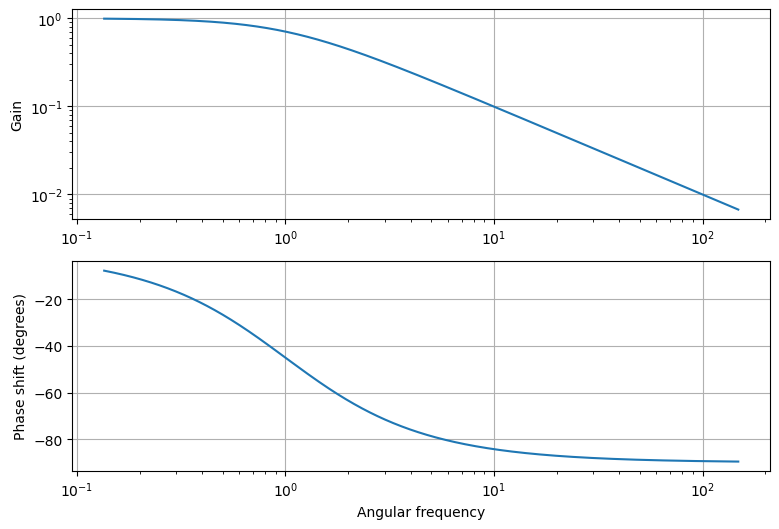

In [13]:
w_filter = 1
mag = lambda w: w_filter / np.sqrt(w_filter**2 + w**2)
arg = lambda w: np.arctan(-w / w_filter)
bode(mag, arg)
plt.show()

For most purposes, the top panel is the most interesting: showing how the gain starts at 1 but then rapidly decreases for higher frequencies.

### A first-order high-pass filter

We'll use
\begin{align}
H(s) = \frac{s}{s + \omega}
\end{align}
so that
\begin{align}
H(i\phi) &= \frac{i\phi}{\omega+i\phi} = \frac{\phi^2 + i\omega\phi}{\omega^2-\phi^2} \\
|H(i\phi)| &= \frac{|i\phi|}{|\omega+i\phi|} = \frac{\phi}{\sqrt{\omega^2+\phi^2}} \\
\angle H(i\phi) &= \arctan(\omega / \phi)
\end{align}

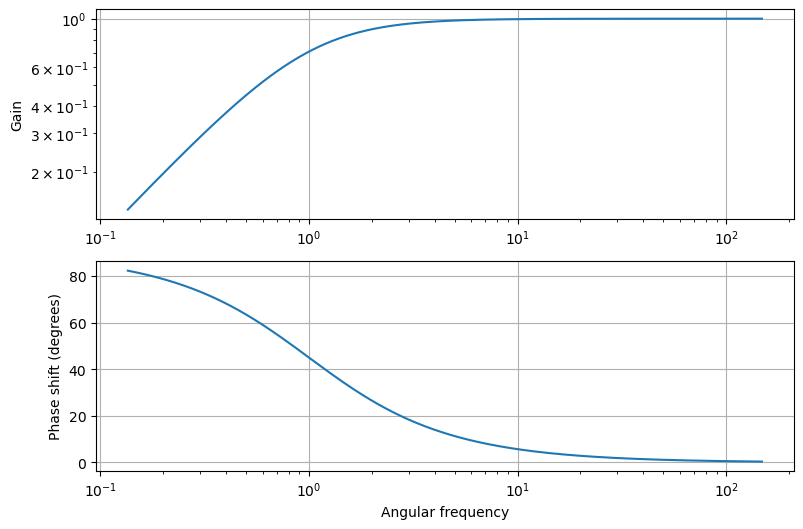

In [14]:
w_filter = 1
mag = lambda w: w / np.sqrt(w_filter**2 + w**2)
arg = lambda w: np.arctan(w_filter / w)
bode(mag, arg)
plt.show()

Here we see a very similar phase shift, but now the filter has gain 1 for high frequencies, and the gain decreases as the frequency is _lowered_.

### A second-order system as a filter

Second order systems arise in many situations.

Starting from a form found in the previous notebook
\begin{align}
H(s) = \frac{1}{s^2 + 2 \zeta \omega s + \omega^2}
\end{align}
we can derive
\begin{align}
|H(i\phi)| &= \frac{1}{\sqrt{(\omega^2 - \phi^2)^2 + (2\zeta\omega\phi)^2}} \\
\angle H(i\phi) &= \operatorname{atan2} \left(2\zeta\omega\phi, \omega^2 + \phi^2 \right)
\end{align}

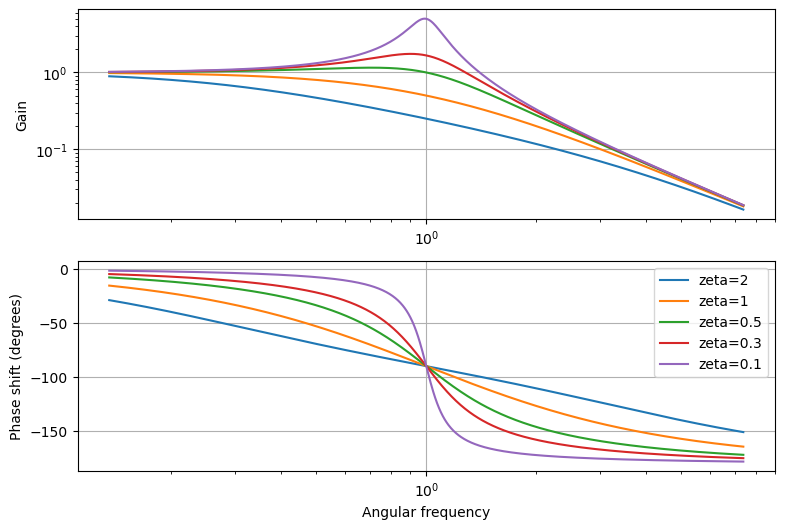

In [15]:
w_filter = 1
mag = lambda w, zeta: 1 / np.sqrt((w_filter**2 - w**2)**2 + (2*zeta*w_filter*w)**2)
arg = lambda w, zeta: np.arctan2(-2*zeta*w*w_filter, w_filter**2 - w**2)
w_hi = 100
axes = bode(mag, arg, hi=w_hi, zeta=2)
axes = bode(mag, arg, axes, hi=w_hi, zeta=1)
axes = bode(mag, arg, axes, hi=w_hi, zeta=0.5)
axes = bode(mag, arg, axes, hi=w_hi, zeta=0.3)
axes = bode(mag, arg, axes, hi=w_hi, zeta=0.1)
plt.show()